In [160]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

# Load CSV file
df = pd.read_csv('/Users/starrism/Desktop/243/code/new_coursera_full.csv')
print("Dataset Shape:", df.shape)

Dataset Shape: (18910, 11)


### 1. Count missing values for each column (including NaN, None, empty strings, and 0)

In [161]:
missing_count = []
for col in df.columns:
    null_count = df[col].isnull().sum()
    zero_count = ((df[col] == 0) | (df[col] == '0')).sum() if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'float64' else 0
    total_missing = null_count + zero_count
    missing_count.append({
        'Column': col,
        'Null_Count': null_count,
        'Zero_Count': zero_count,
        'Missing_Count': total_missing,
        'Missing_Percentage': round(total_missing / len(df) * 100, 2),
    })

missing_stats = pd.DataFrame(missing_count)
missing_stats = missing_stats.sort_values('Missing_Count', ascending=False)

print("\n" + "="*80)
print("Missing Values Statistics (Including 0 as Missing)")
print("="*80 + "\n")
print(missing_stats.to_string(index=False))


Missing Values Statistics (Including 0 as Missing)

          Column  Null_Count  Zero_Count  Missing_Count  Missing_Percentage
         Ratings        9845           0           9845               52.06
        Workload        7660           0           7660               40.51
    Review_Count           0        5387           5387               28.49
Difficulty_Level        2166           0           2166               11.45
          Skills           1           0              1                0.01
     Course_Name           0           0              0                0.00
    Organization           0           0              0                0.00
        Language           0           0              0                0.00
     Course_Link           0           0              0                0.00
   Payment_Model           0           0              0                0.00
     Course_Type           0           0              0                0.00


In [162]:
print("Before removing rows with missing Skills: "+f"{len(df)}")

# Remove rows where Skills is null or empty
df_cleaned = df[df['Skills'].notna() & (df['Skills'].str.strip() != '')]

print("After removing rows with missing Skills: "+f"{len(df_cleaned)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")

Before removing rows with missing Skills: 18910
After removing rows with missing Skills: 18909
Rows removed: 1


### 2. Workload Standardization


In [163]:
def clean_and_convert(text):
    original = str(text)
    if pd.isna(text) or original.strip() == '' or original.lower() == 'nan':
        return pd.Series([np.nan, "Original Missing"])
    
    t = original.lower().strip()

    # 1. Handle ranges (e.g., "2-4") immediately
    range_pattern = r'(\d+(?:\.\d+)?)\s*[-–—~至]\s*(\d+(?:\.\d+)?)'
    def replace_range(m):
        return str((float(m.group(1)) + float(m.group(2))) / 2)
    t = re.sub(range_pattern, replace_range, t)

    # 2. Check for "Hours per Week" pattern
    # Matches: "2.5 hours a week", "3h/week", "4 hours/w"
    per_week_match = re.search(r'(\d+(?:\.\d+)?)\s*(?:hour|h|hr|小时|час).*(?:per|a|/|每周)\s*(?:week|w|周|недел)', t)
    
    # Check for "Total Weeks" pattern 
    # Matches: "4 weeks", "5 semanas"
    weeks_match = re.search(r'(\d+(?:\.\d+)?)\s*(?:week|sem|周|недел)', t)

    if per_week_match and weeks_match:
        # Scenario: "4 weeks... 3 hours a week" -> 4 * 3 = 12
        hours_per_week = float(per_week_match.group(1))
        total_weeks = float(weeks_match.group(1))
        return pd.Series([hours_per_week * total_weeks, "Success (Weekly Calculation)"])

    # 3. Handle "X hours Y minutes" (e.g., 4h 30m)
    # This regex looks for hours and minutes specifically to combine them
    h_m_match = re.search(r'(\d+(?:\.\d+)?)\s*(?:hour|h|hr|小时|час)\s*(\d+(?:\.\d+)?)\s*(?:min|m|分)', t)
    if h_m_match:
        total = float(h_m_match.group(1)) + (float(h_m_match.group(2)) / 60)
        return pd.Series([total, "Success (H+M Combination)"])

    # 4. Standard Unit Extraction (Fallbacks)
    # Total Weeks only
    if weeks_match:
        return pd.Series([float(weeks_match.group(1)) * 10, "Success (Total Weeks Only)"])
    
    # Total Hours only
    hours_only = re.search(r'(\d+(?:\.\d+)?)\s*(?:hour|h|hr|小时|час)', t)
    if hours_only:
        return pd.Series([float(hours_only.group(1)), "Success (Total Hours)"])
    
    # Minutes only
    mins_only = re.search(r'(\d+(?:\.\d+)?)\s*(?:min|m|分)', t)
    if mins_only:
        return pd.Series([float(mins_only.group(1)) / 60, "Success (Minutes Only)"])

    # 5. Last Resort: Just a number
    just_num = re.search(r'(\d+(?:\.\d+)?)', t)
    if just_num:
        return pd.Series([float(just_num.group(1)), "Success (Numeric Fallback)"])

    return pd.Series([np.nan, "Unrecognized Format"])

In [164]:
# --- Execution ---
audit_results = df_cleaned['Workload'].apply(clean_and_convert)
audit_results.columns = ['Converted_Hours', 'Status']

# --- Summary & Export ---
print(audit_results['Status'].value_counts())

# Filter failed rows to see what's wrong
failed_rows = audit_results[audit_results['Status'].isin(["No Numbers Found", "Unrecognized Unit"])]
failed_rows.to_csv("conversion_failures.csv", index=False)

Status
Original Missing                7660
Success (Weekly Calculation)    4287
Success (Total Hours)           3931
Success (Total Weeks Only)      1254
Success (Minutes Only)          1008
Success (Numeric Fallback)       413
Unrecognized Format              188
Success (H+M Combination)        168
Name: count, dtype: int64


In [165]:
df_cleaned['Workload_Hour'] = audit_results['Converted_Hours']
df_cleaned[['Workload','Workload_Hour']].head(30)

/var/folders/x1/_95hmylj2094b8ktc_sqsv340000gn/T/ipykernel_72727/1262941457.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Workload_Hour'] = audit_results['Converted_Hours']


,Workload,Workload_Hour
0,NaN,NaN
1,1 hour 30 minutes,1.500000
2,"4 weeks of study, 2-4 hours a week",12.000000
3,1 hour 30 minutes,1.500000
4,2 heures,2.000000
5,4-8 hours/week,6.000000
6,4h 30m,4.500000
7,2 hours,2.000000
8,"4 weeks of study, 1-2 hours/week",6.000000
9,NaN,NaN


In [166]:
# make sure the hour column is immediately after the original workload column
cols = df_cleaned.columns.tolist()
if 'Workload' in cols and 'Workload_Hour' in cols:
    cols.remove('Workload_Hour')
    idx = cols.index('Workload') + 1
    cols.insert(idx, 'Workload_Hour')
    df_cleaned = df_cleaned[cols]

# verify column order and write out
print(df_cleaned.columns.tolist())
df_cleaned.to_csv('new_coursera_full_clean.csv', index=False)

['Course_Name', 'Skills', 'Organization', 'Ratings', 'Review_Count', 'Workload', 'Workload_Hour', 'Difficulty_Level', 'Language', 'Course_Link', 'Payment_Model', 'Course_Type']


### 3. EDA


a) Top 20 Skills

/var/folders/x1/_95hmylj2094b8ktc_sqsv340000gn/T/ipykernel_72727/3716752910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(skills), x=list(freqs), palette=colors)


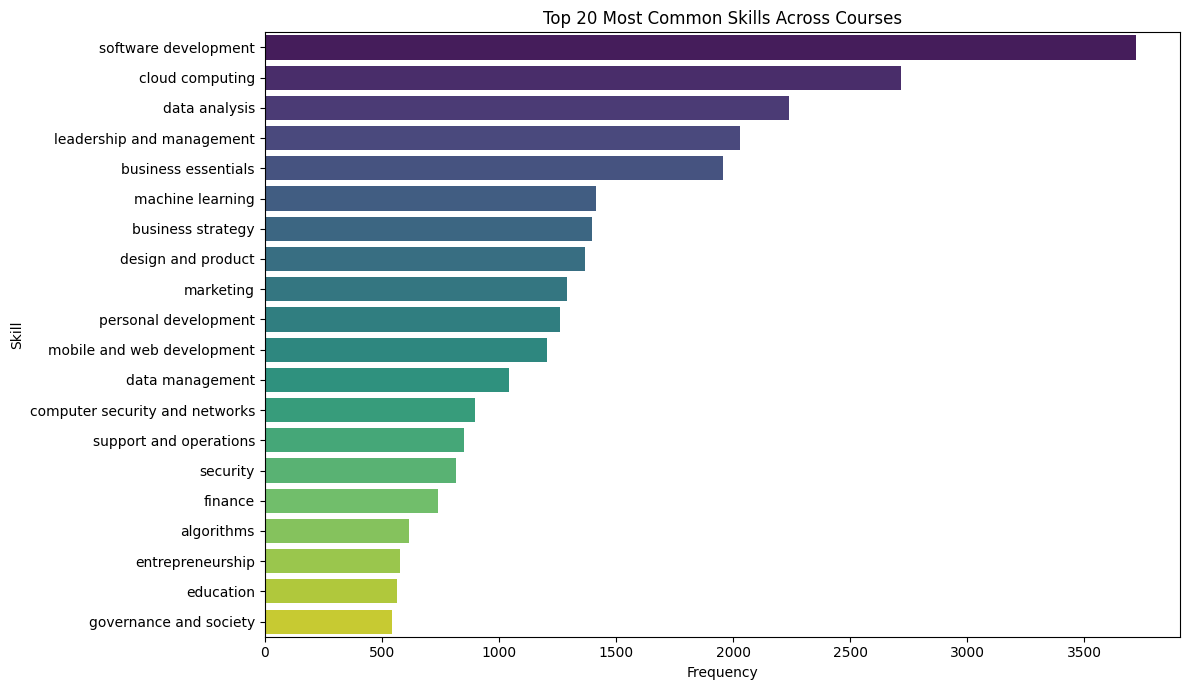

In [167]:
def parse_skills_cell(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    # Try Python list-like string
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(i).strip().lower() for i in v if str(i).strip()]
    except Exception:
        pass
    # Fallback: split by common separators
    parts = re.split(r"[;,/|\n]+", s)
    return [p.strip().lower() for p in parts if p.strip()]

if "Skills" in df_cleaned.columns:
    skill_counter = Counter()

    for cell in df_cleaned["Skills"]:
        for sk in parse_skills_cell(cell):
            skill_counter[sk] += 1

    top_n = 20
    top_items = skill_counter.most_common(top_n)

    if len(top_items) > 0:
        skills, freqs = zip(*top_items)
        plt.figure(figsize=(12, 7))
        plt.barh(skills, freqs, color=colors)
        sns.barplot(y=list(skills), x=list(freqs), palette=colors)
        plt.title(f"Top {top_n} Most Common Skills Across Courses")
        plt.xlabel("Frequency")
        plt.ylabel("Skill")
        plt.tight_layout()
        plt.show()
    else:
        print("No skills parsed. Please check the 'Skills' column format.")
else:
    print("Column 'Skills' not found.")


b) Ratings histogram with mean

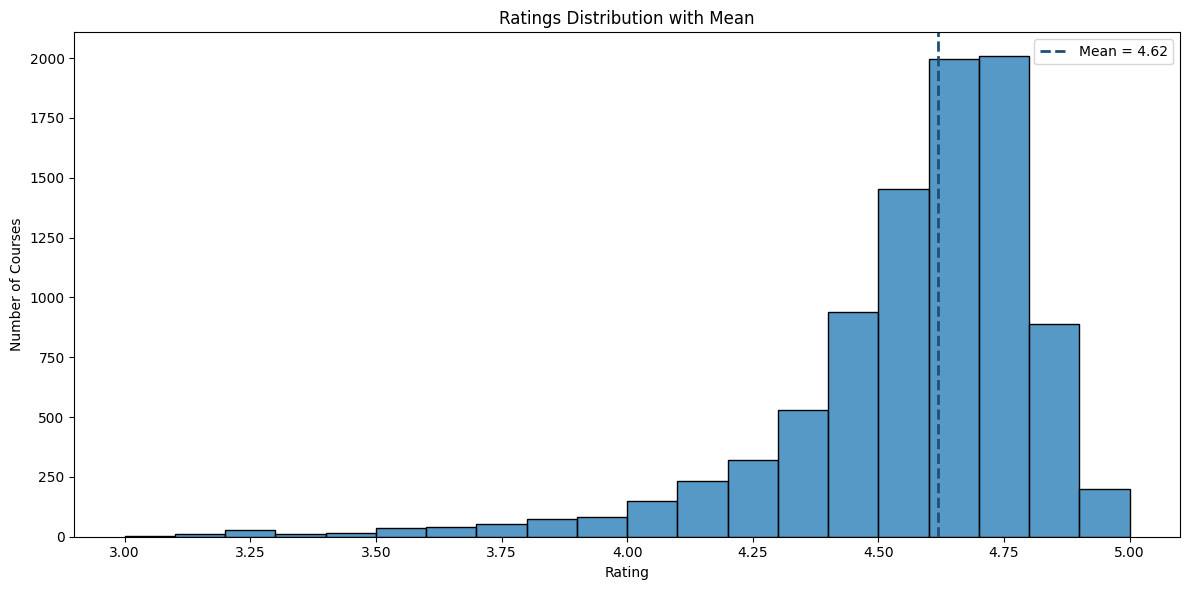

In [168]:
# Ratings histogram with mean reference lines
ratings = df_cleaned["Ratings"].dropna()

mean_val = ratings.mean()

plt.figure(figsize=(12, 6))
bin_edges = np.arange(3.0, 5.01, 0.1)
sns.histplot(ratings, bins=bin_edges)
plt.title("Ratings Distribution with Mean")
plt.xlabel("Rating")
plt.ylabel("Number of Courses")

plt.axvline(mean_val, color='#1F4E79', linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")

plt.legend()
plt.tight_layout()
plt.show()


c) Top 20 Organizations by Course Count with Average Rating

Top 20 Organizations Statistics:

Rank  Organization                                  Courses    Avg Rating     
----------------------------------------------------------------------------------------------------
1     Coursera                                      2762       4.51           
2     Google Cloud                                  1657       4.54           
3     Packt                                         1520       4.59           
4     EDUCBA                                        893        4.73           
5     University of Colorado Boulder                421        4.58           
6     Google                                        371        4.79           
7     University of Michigan                        318        4.69           
8     Johns Hopkins University                      317        4.64           
9     University of Illinois Urbana-Champaign       275        4.62           
10    Microsoft                                     274        4.58        

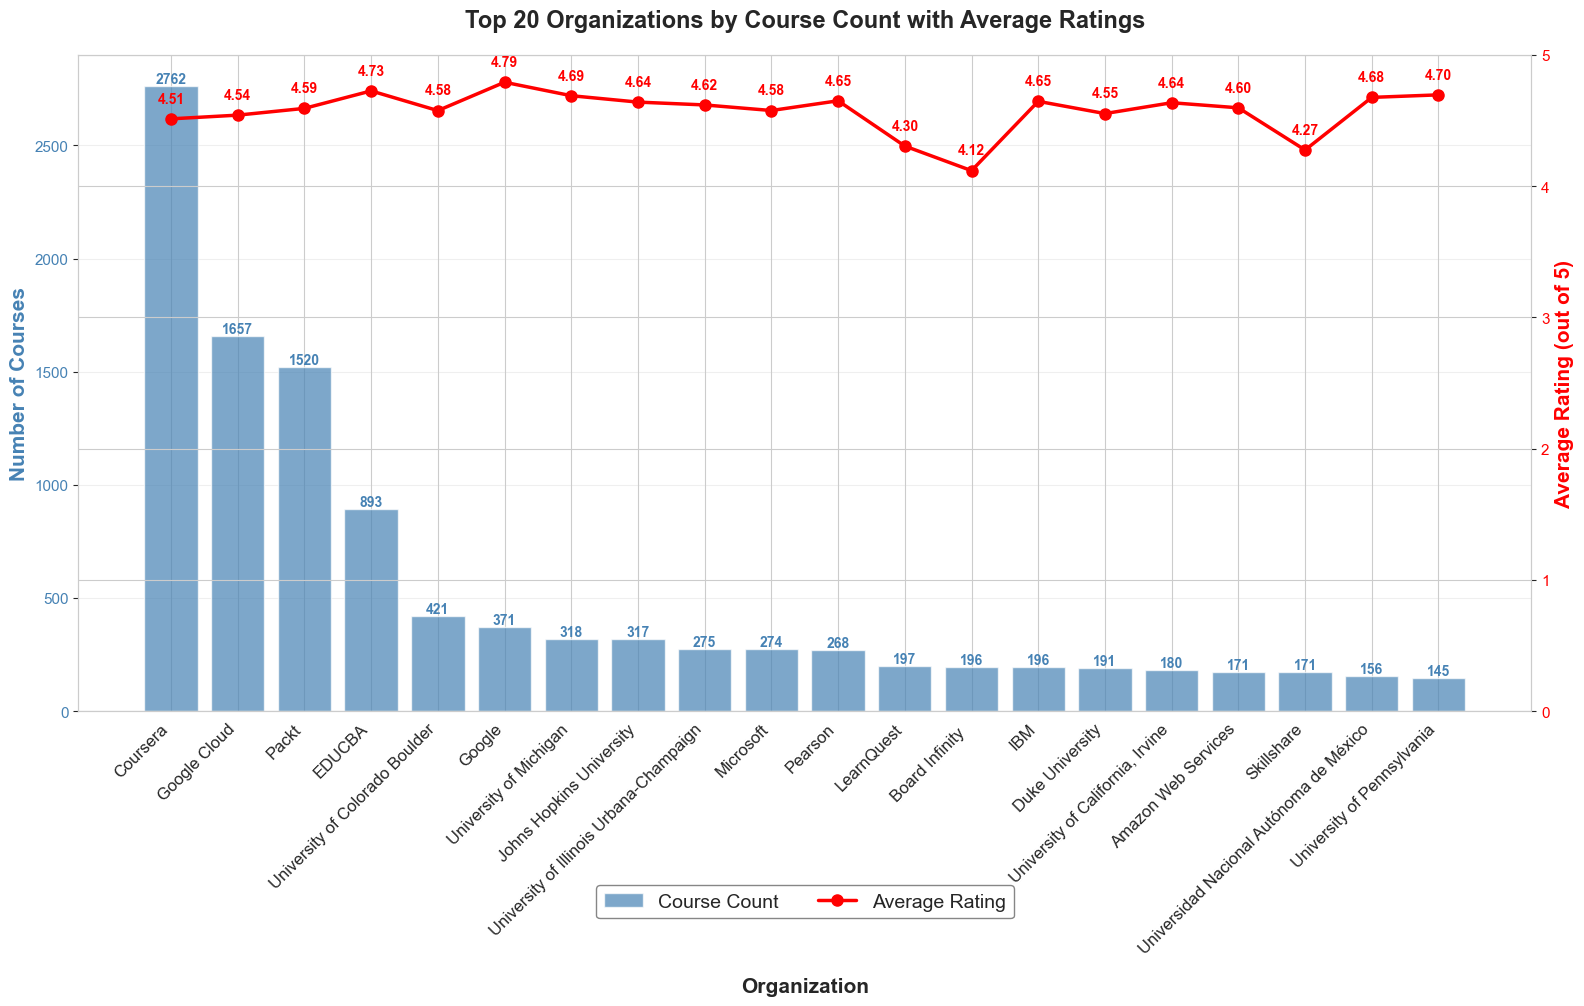


Summary Statistics:

Average Ratings (for 20 orgs with ratings):
  Mean rating: 4.57
  Median rating: 4.61
  Min rating: 4.12
  Max rating: 4.79


In [169]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['font.size'] = 12

# Get organization statistics
org_stats = df_cleaned.groupby('Organization').agg({
    'Course_Name': 'count',  # Number of courses
    'Ratings': lambda x: x.dropna().mean()  # Average ratings (excluding NaN)
}).rename(columns={'Course_Name': 'Course_Count', 'Ratings': 'Avg_Rating'})

# Get top 20 organizations by course count
top_20_orgs = org_stats.nlargest(20, 'Course_Count')

print("Top 20 Organizations Statistics:")
print("="*100)
print(f"\n{'Rank':<5} {'Organization':<45} {'Courses':<10} {'Avg Rating':<15}")
print("-"*100)

for rank, (org, row) in enumerate(top_20_orgs.iterrows(), 1):
    courses = int(row['Course_Count'])
    avg_rating = row['Avg_Rating']
    rating_str = f"{avg_rating:.2f}" if pd.notna(avg_rating) else "N/A"
    print(f"{rank:<5} {org:<45} {courses:<10} {rating_str:<15}")

# Create visualization
fig, ax = plt.subplots(figsize=(16, 9))

# Prepare data
x_pos = range(len(top_20_orgs))
course_counts = top_20_orgs['Course_Count'].values
avg_ratings = top_20_orgs['Avg_Rating'].values
orgs = top_20_orgs.index

# Create bar plot for course counts
bars = ax.bar(x_pos, course_counts, color='steelblue', alpha=0.7, label='Course Count')

# Add secondary y-axis for ratings
ax2 = ax.twinx()
line = ax2.plot(x_pos, avg_ratings, color='red', marker='o', linewidth=2.5, 
                markersize=8, label='Average Rating', linestyle='-')

# Customize primary axis (course count)
ax.set_xlabel('Organization', fontsize=15, fontweight='bold', labelpad=15)
ax.set_ylabel('Number of Courses', fontsize=15, fontweight='bold', color='steelblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(orgs, rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelcolor='steelblue', labelsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Customize secondary axis (average rating)
ax2.set_ylabel('Average Rating (out of 5)', fontsize=15, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red', labelsize=11)
ax2.set_ylim([0, 5])

# Add value labels on bars
for i, (bar, rating) in enumerate(zip(bars, avg_ratings)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='steelblue')
    
    if pd.notna(rating):
        ax2.text(i, rating + 0.1, f'{rating:.2f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')

# Title and legend
plt.title('Top 20 Organizations by Course Count with Average Ratings', 
          fontsize=17, fontweight='bold', pad=20)

# Combine legends - place at bottom center, outside plot area
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, 
         loc='upper center', bbox_to_anchor=(0.5, -0.25),
         fontsize=14, framealpha=0.95, edgecolor='gray', ncol=2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Extra space for legend
plt.show()

print("\n" + "="*100)
print("Summary Statistics:")
print("="*100)

# Rating statistics (excluding NaN)
valid_ratings = top_20_orgs['Avg_Rating'].dropna()
if len(valid_ratings) > 0:
    print(f"\nAverage Ratings (for {len(valid_ratings)} orgs with ratings):")
    print(f"  Mean rating: {valid_ratings.mean():.2f}")
    print(f"  Median rating: {valid_ratings.median():.2f}")
    print(f"  Min rating: {valid_ratings.min():.2f}")
    print(f"  Max rating: {valid_ratings.max():.2f}")
    
    orgs_without_rating = len(top_20_orgs) - len(valid_ratings)
    if orgs_without_rating > 0:
        print(f"\n  Orgs without rating data: {orgs_without_rating}")


d) Pairwise Relationships among Aggregated Metrics (ratings/review count/workload hour/difficulty) for skills

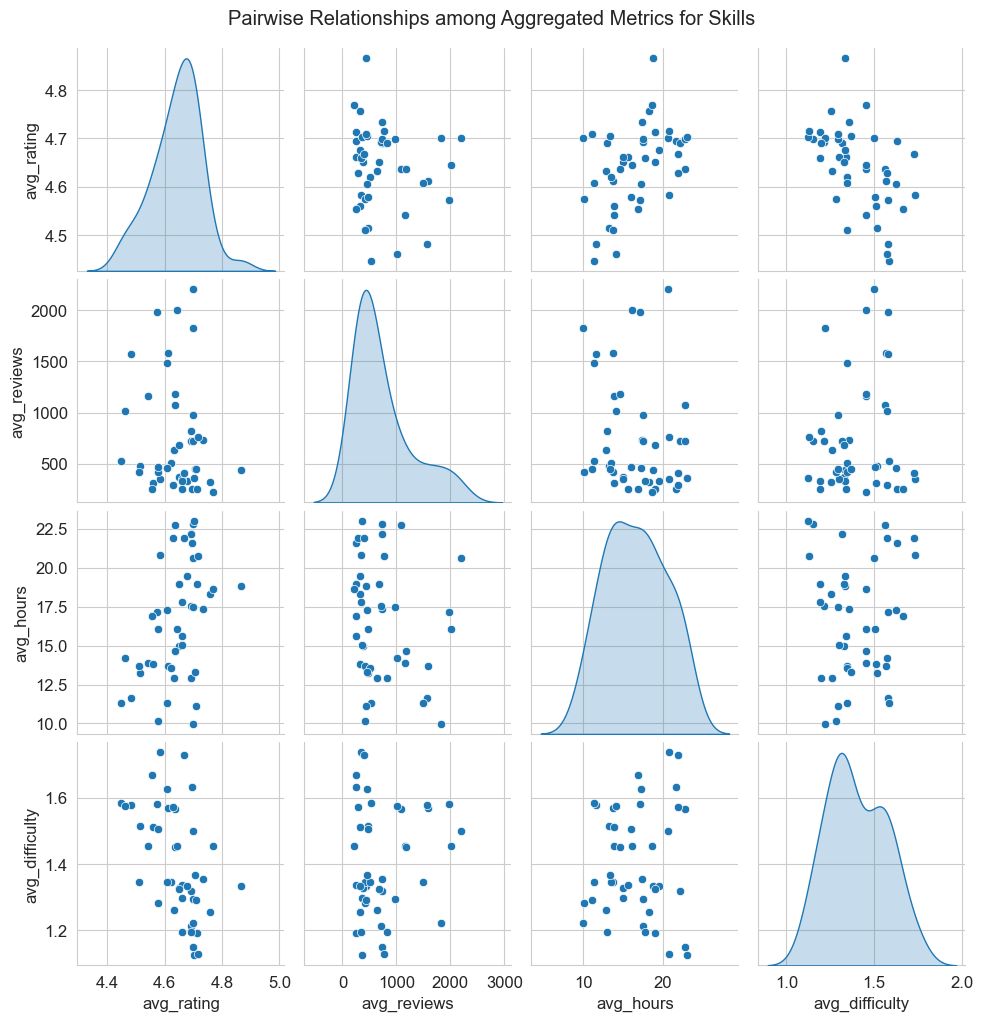

In [171]:
# aggregate everything by skill
expl = df_cleaned[['Skills','Ratings','Review_Count',
                   'Workload_Hour','Difficulty_Level']].copy()
expl['Skill'] = expl['Skills'].apply(parse_skills_cell)
expl = expl.explode('Skill')

difficulty_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
expl['Difficulty_Num'] = expl['Difficulty_Level'].map(difficulty_map)

# drop rows that do not have any of the fields we care about
expl = expl.dropna(subset=['Skill','Workload_Hour','Ratings',
                           'Review_Count','Difficulty_Num'])

# aggregate per skill
skill_agg = (expl.groupby('Skill')
                .agg(avg_rating=('Ratings','mean'),
                     avg_reviews=('Review_Count','mean'),
                     avg_hours=('Workload_Hour','mean'),
                     avg_difficulty=('Difficulty_Num','mean'),
                     count=('Skill','size'))
                .reset_index())

# pairwise relationships between the numeric summaries
sns.pairplot(skill_agg[['avg_rating','avg_reviews','avg_hours','avg_difficulty']],
             diag_kind='kde')
plt.suptitle('Pairwise Relationships among Aggregated Metrics for Skills',
             y=1.02)
plt.show()

e) notable columns

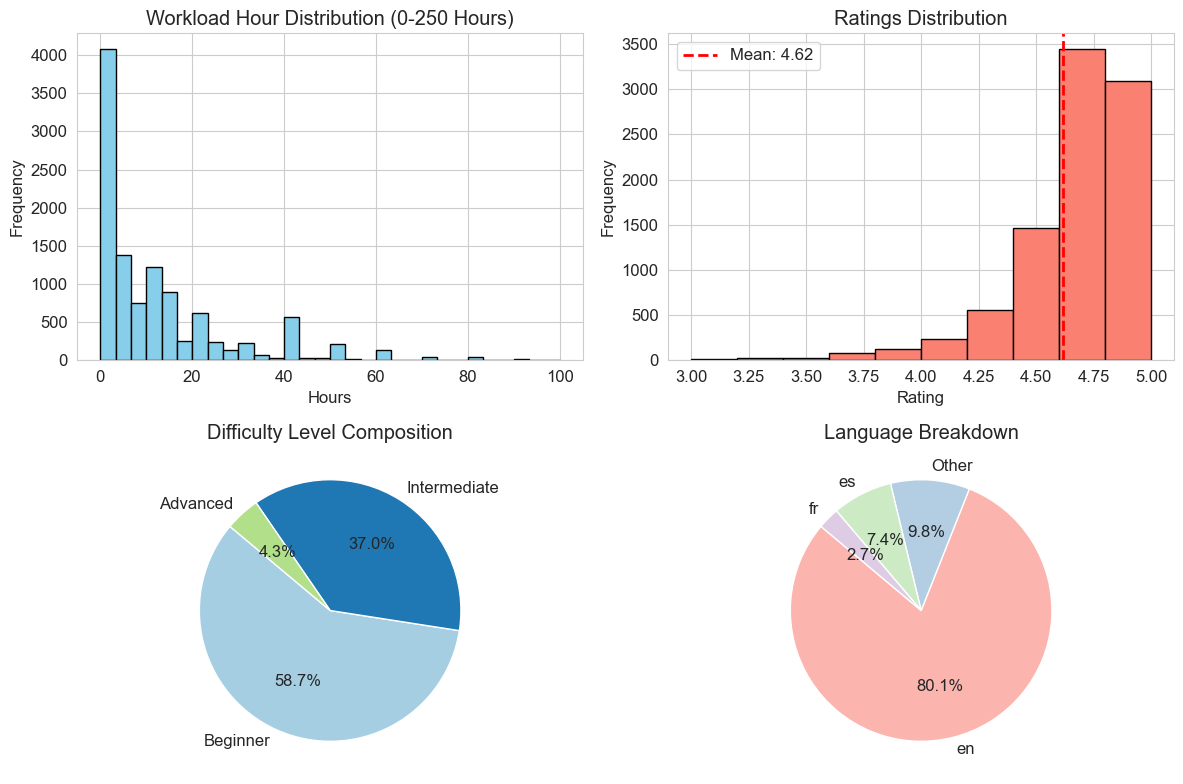

In [172]:
lang_series = df_cleaned["Language"].copy()
lang_series[~lang_series.isin(['en', 'fr', 'es'])] = 'Other'
language_counts = lang_series.value_counts()

# Calculate the mean for the vertical line
mean_rating = df_cleaned["Ratings"].mean()

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# 1. Workload_Hour Histogram (Top Left) - Limited to 250
df_cleaned["Workload_Hour"].hist(ax=axes[0, 0], bins=30, range=(0, 100), color='skyblue', edgecolor='black')
axes[0, 0].set_title("Workload Hour Distribution (0-250 Hours)")
axes[0, 0].set_xlabel("Hours")
axes[0, 0].set_ylabel("Frequency")

# 2. Ratings Distribution (Top Right) with Mean Line
df_cleaned["Ratings"].hist(ax=axes[0, 1], bins=10, color='salmon', edgecolor='black')
axes[0, 1].axvline(mean_rating, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_rating:.2f}')
axes[0, 1].set_title("Ratings Distribution")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

# 3. Difficulty Level Composition (Bottom Left) - Pie Chart
difficulty_counts = df_cleaned["Difficulty_Level"].value_counts()
axes[1, 0].pie(difficulty_counts, labels=difficulty_counts.index, autopct='%1.1f%%', 
               startangle=140, colors=plt.cm.Paired.colors)
axes[1, 0].set_title("Difficulty Level Composition")

# 4. Language Breakdown (Bottom Right) - Pie Chart
axes[1, 1].pie(language_counts, 
       labels=language_counts.index, 
       autopct='%1.1f%%', 
       startangle=140, 
       colors=plt.cm.Pastel1.colors)
axes[1, 1].set_title("Language Breakdown")

# Tight layout to ensure no overlap for PPT pasting
plt.tight_layout()
plt.show()